# UUAS Evaluation — Step by Step

In [52]:
import torch, numpy as np, matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import deque
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import minimum_spanning_tree
from transformers import AutoTokenizer, AutoModel

DEVICE, MODEL_NAME, PROBE_RANK = torch.device('cuda' if torch.cuda.is_available() else 'cpu'), 'gpt2', 256

# --- helpers ---
def tree_distances(heads):
    N, adj = len(heads), [[] for _ in range(len(heads))]
    for i, h in enumerate(heads):
        if h > 0: adj[i].append(h-1); adj[h-1].append(i)
    dist = np.full((N, N), np.inf); np.fill_diagonal(dist, 0)
    for s in range(N):
        q, seen = deque([(s,0)]), {s}
        while q:
            n, d = q.popleft(); dist[s,n] = d
            for nb in adj[n]:
                if nb not in seen: seen.add(nb); q.append((nb, d+1))
    return dist

def gold_edges(heads):
    return {frozenset([i, h-1]) for i, h in enumerate(heads) if h > 0}

def mst_edges(dist_matrix):
    mst = minimum_spanning_tree(csr_matrix(dist_matrix)).tocoo()
    return {frozenset([int(i), int(j)]) for i, j in zip(mst.row, mst.col)}

def predict_distances(h, B):
    z = h @ B; diff = z.unsqueeze(1) - z.unsqueeze(0)
    return (diff**2).sum(-1).numpy()

def uuas(pred, gold):
    return len(pred & gold) / len(gold) if gold else 0.0

def draw_parse(words, heads, edge_set, title='', ax=None, highlight=None):
    """Arc diagram with ROOT node. highlight = set of correct frozensets (green/red colouring)."""
    if ax is None: _, ax = plt.subplots(figsize=(max(6, len(words)*1.2), 3.2))
    n    = len(words)
    root = next(i for i, h in enumerate(heads) if h == 0)   # root word index

    # word boxes
    for i, w in enumerate(words):
        ax.text(i, 0, w, ha='center', va='center', fontsize=10,
                bbox=dict(boxstyle='round,pad=0.35', fc='#dceeff', ec='#5599cc', lw=1.2))

    # ROOT node above root word
    ax.text(root, 1.6, 'ROOT', ha='center', va='center', fontsize=9, color='white',
            bbox=dict(boxstyle='round,pad=0.3', fc='#555', ec='#333', lw=1))
    ax.annotate('', xy=(root, 0.28), xytext=(root, 1.42),
                arrowprops=dict(arrowstyle='->', color='#555', lw=1.5))

    # dependency arcs
    for edge in edge_set:
        i, j = sorted(edge)
        color = 'black' if highlight is None else ('#2ecc71' if edge in highlight else '#e74c3c')
        span  = (j - i)
        arc   = mpatches.Arc((( i+j)/2, 0), width=span, height=span*0.55,
                              angle=0, theta1=0, theta2=180, color=color, lw=1.8)
        ax.add_patch(arc)
        ax.annotate('', xy=(j, 0.01), xytext=(j-0.01, span*0.27),
                    arrowprops=dict(arrowstyle='->', color=color, lw=1.5))

    ax.set_xlim(-0.8, n-0.2); ax.set_ylim(-0.5, 2.1)
    ax.axis('off'); ax.set_title(title, fontsize=11)

print('helpers ready')

helpers ready


---
## Step 1 — Sentence + dependency heads

`heads[i]` = 1-indexed head of word `i` &nbsp;(0 = ROOT)

In [53]:
words = ['The', 'cat', 'sat', 'on', 'the', 'mat']
heads = [  2,     3,     0,    3,    6,     4  ]

for i, (w, h) in enumerate(zip(words, heads)):
    print(f'  [{i}] {w:10s}  ->  {words[h-1] if h > 0 else "ROOT"}')

  [0] The         ->  cat
  [1] cat         ->  sat
  [2] sat         ->  ROOT
  [3] on          ->  sat
  [4] the         ->  mat
  [5] mat         ->  on


---
## Step 2 — Gold tree distances + gold edges

Gold edges:
  The -- cat
  cat -- sat
  sat -- on
  on -- mat
  the -- mat


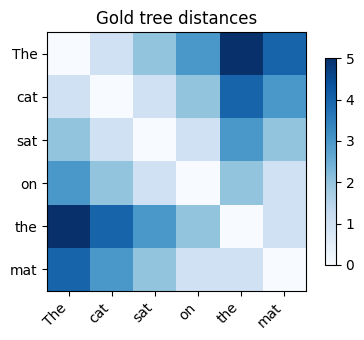

In [54]:
gold_dist = tree_distances(heads)
gold      = gold_edges(heads)

print('Gold edges:'); [print(f'  {words[i]} -- {words[j]}') for i,j in sorted([sorted(e) for e in gold])]

plt.figure(figsize=(4.5,3.5))
plt.imshow(gold_dist, cmap='Blues')
plt.xticks(range(len(words)), words, rotation=45, ha='right')
plt.yticks(range(len(words)), words)
plt.title('Gold tree distances'); plt.colorbar(shrink=0.8); plt.tight_layout(); plt.show()

---
## Step 3 — Gold parse tree (arc diagram)

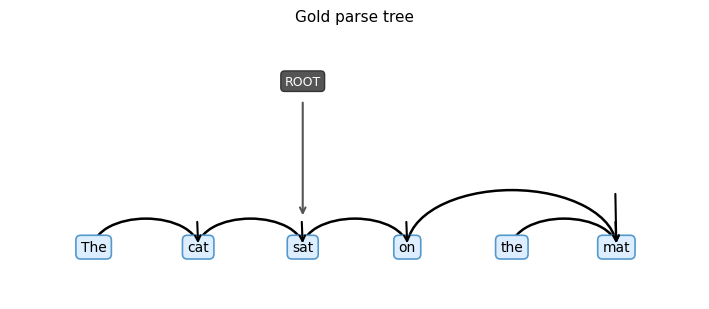

In [55]:
fig, ax = plt.subplots(figsize=(max(6, len(words)*1.2), 3.2))
draw_parse(words, heads, gold, title='Gold parse tree', ax=ax)
plt.tight_layout(); plt.show()

---
## Step 4 — Extract hidden states (all layers)

Average subword tokens per word, then subtract embedding layer: $h^\ell_i = h^\ell_i - h^0_i$

In [56]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None: tokenizer.pad_token = tokenizer.eos_token
model = AutoModel.from_pretrained(MODEL_NAME, output_hidden_states=True).to(DEVICE).eval()
N_LAYERS, HIDDEN_DIM = model.config.num_hidden_layers, model.config.hidden_size
print(f'{MODEL_NAME}: {N_LAYERS} layers, hidden_dim={HIDDEN_DIM}')

@torch.no_grad()
def get_word_states(words):
    enc = tokenizer(words, is_split_into_words=True, return_tensors='pt', add_special_tokens=True).to(DEVICE)
    w2t = {};
    [w2t.setdefault(w,[]).append(t) for t,w in enumerate(enc.word_ids()) if w is not None]
    layers = [torch.stack([hs[0].cpu()[w2t[i]].mean(0) for i in range(len(words))]) for hs in model(**enc).hidden_states]
    return [layers[0]] + [l - layers[0] for l in layers[1:]]

all_layers = get_word_states(words)
print(f'Shape per layer: {all_layers[1].shape}')

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

gpt2: 12 layers, hidden_dim=768
Shape per layer: torch.Size([6, 768])


---
## Step 5 — Load trained B (or use random)

Run `probe_train_toy.ipynb` first to generate `probe_B.pt`.  
A random B is shown for comparison — it performs at chance level.

In [ ]:
import os

if os.path.exists('probe_B.pt'):
    ckpt  = torch.load('probe_B.pt', weights_only=True)
    B     = ckpt['B']
    LAYER = ckpt['layer']
    print(f'Loaded trained B  shape={tuple(B.shape)}  layer={LAYER}  model={ckpt["model"]}')
else:
    torch.manual_seed(42)
    B = torch.randn(HIDDEN_DIM, PROBE_RANK) * 0.05
    print(f'probe_B.pt not found — using random B  shape={tuple(B.shape)}')

---
## Step 6 — Predict distances + build MST

$$\hat{d}_{ij} = \|B^\top(h_i - h_j)\|^2 \quad \xrightarrow{\text{MST}} \quad \text{predicted tree}$$

Layer 6  |  UUAS = 0.400
Predicted edges:
  The -- sat  WRONG
  cat -- on  WRONG
  sat -- on  OK
  on -- the  WRONG
  on -- mat  OK


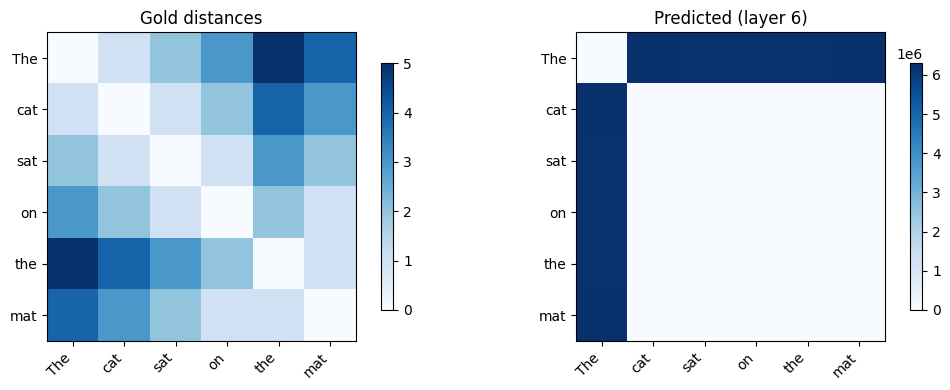

{frozenset({3, 4}),
 frozenset({2, 3}),
 frozenset({0, 2}),
 frozenset({3, 5}),
 frozenset({1, 3})}

In [58]:
LAYER      = 6
pred_dist  = predict_distances(all_layers[LAYER], B)
pred_edges = mst_edges(pred_dist)
score      = uuas(pred_edges, gold)

print(f'Layer {LAYER}  |  UUAS = {score:.3f}')
print('Predicted edges:')
[print(f'  {words[i]} -- {words[j]}  {"OK" if frozenset([i,j]) in gold else "WRONG"}') for i,j in sorted([sorted(e) for e in pred_edges])]

# Heatmaps
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, mat, t in zip(axes, [gold_dist, pred_dist], ['Gold distances', f'Predicted (layer {LAYER})']):
    im = ax.imshow(mat, cmap='Blues')
    ax.set_xticks(range(len(words))); ax.set_xticklabels(words, rotation=45, ha='right')
    ax.set_yticks(range(len(words))); ax.set_yticklabels(words)
    ax.set_title(t); plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout(); plt.show()
pred_edges

---
## Step 7 — Gold vs Predicted parse graph

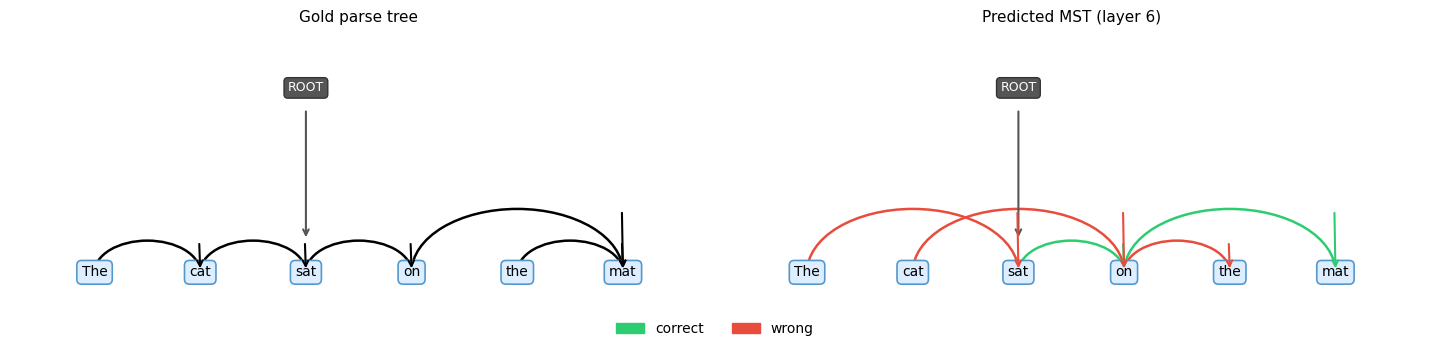

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(max(12, len(words)*2.4), 3.5))
draw_parse(words, heads, gold,       title='Gold parse tree',            ax=axes[0])
draw_parse(words, heads, pred_edges, title=f'Predicted MST (layer {LAYER})',
           ax=axes[1], highlight=gold & pred_edges)
fig.legend(handles=[mpatches.Patch(color='#2ecc71', label='correct'),
                    mpatches.Patch(color='#e74c3c', label='wrong')],
           loc='lower center', ncol=2, frameon=False)
plt.tight_layout(); plt.show()

---
## Step 8 — UUAS across all layers

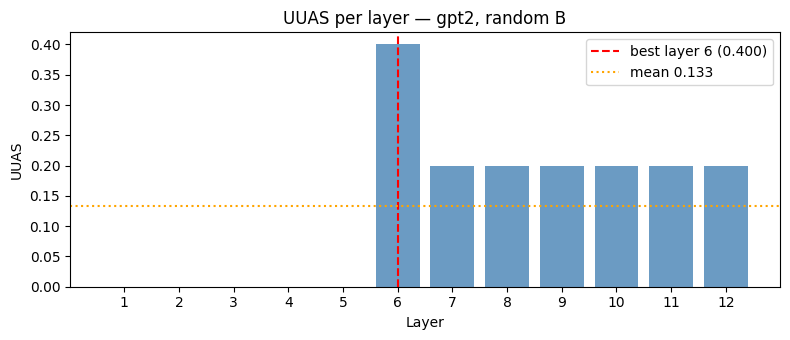

In [60]:
layer_scores = [uuas(mst_edges(predict_distances(all_layers[l], B)), gold) for l in range(1, N_LAYERS+1)]
best         = int(np.argmax(layer_scores)) + 1

layers = list(range(1, N_LAYERS+1))
plt.figure(figsize=(8, 3.5))
plt.bar(layers, layer_scores, color='steelblue', alpha=0.8)
plt.axvline(best, color='red',    linestyle='--', label=f'best layer {best} ({max(layer_scores):.3f})')
plt.axhline(np.mean(layer_scores), color='orange', linestyle=':', label=f'mean {np.mean(layer_scores):.3f}')
plt.xlabel('Layer'); plt.ylabel('UUAS')
plt.title(f'UUAS per layer — {MODEL_NAME}, random B')
plt.xticks(layers); plt.legend(); plt.tight_layout(); plt.show()